In [16]:
#STEP 1: IMPORTING REQUIRED LIBRARIes


import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Input, Conv2D, BatchNormalization, Activation,
                                     MaxPooling2D, GlobalAveragePooling2D, Dense, Dropout)
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.metrics import classification_report, confusion_matrix
import cv2
from PIL import Image


In [17]:
#STEP 2: DEFINE CONFIGURATION VARIABLES

# Set all the paths and parameters

import splitfolders

# Original dataset location
input_folder = r"C:\Users\zaina\Downloads\AI DISEASE PREDICTION\Dataset_BUSI_with_GT"

# New folder to hold the split data
output_folder = r"C:\Users\zaina\Downloads\AI DISEASE PREDICTION\Dataset_BUSI_with_GT_split"

# Split dataset into 70% train, 20% validation, 10% test
splitfolders.ratio(input_folder, output=output_folder, seed=1337, ratio=(.7, .2, .1))





Copying files: 2531 files [00:15, 168.26 files/s]


In [18]:
import os

# ✅ Use the new split dataset folder
DATA_DIR = r"C:\Users\zaina\Downloads\AI DISEASE PREDICTION\Dataset_BUSI_with_GT_split"

# ✅ Define subfolder paths
TRAIN_DIR = os.path.join(DATA_DIR, "train")
VAL_DIR   = os.path.join(DATA_DIR, "val")
TEST_DIR  = os.path.join(DATA_DIR, "test")

# ✅ Define parameters
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 20
CLASSES = ["normal", "benign", "malignant"]
MODEL_PATH = "best_model.h5"

# ✅ Check the folder paths exist
for path in [TRAIN_DIR, VAL_DIR, TEST_DIR]:
    print(path, "->", os.path.exists(path))


C:\Users\zaina\Downloads\AI DISEASE PREDICTION\Dataset_BUSI_with_GT_split\train -> True
C:\Users\zaina\Downloads\AI DISEASE PREDICTION\Dataset_BUSI_with_GT_split\val -> True
C:\Users\zaina\Downloads\AI DISEASE PREDICTION\Dataset_BUSI_with_GT_split\test -> True


In [19]:
!pip install split-folders




[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [20]:
#STEP 3: CREATE DATA GENERATORS

from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(rescale=1./255)
val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

val_gen = val_datagen.flow_from_directory(
    VAL_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

test_gen = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)


Found 3774 images belonging to 3 classes.
Found 1202 images belonging to 3 classes.
Found 596 images belonging to 3 classes.


In [21]:
#STEP 4: BUILD CNN MODEL FROM SCRATCH
def build_cnn_from_scratch(input_shape=(224,224,3), num_classes=3, dropout_rate=0.4):
    inp = Input(shape=input_shape)

    # Block 1
    x = Conv2D(32, (3,3), padding="same")(inp)
    x = BatchNormalization()(x)
    x = Activation("relu")(x)
    x = Conv2D(32, (3,3), padding="same")(x)
    x = BatchNormalization()(x)
    x = Activation("relu")(x)
    x = MaxPooling2D((2,2))(x)

    # Block 2
    x = Conv2D(64, (3,3), padding="same")(x)
    x = BatchNormalization()(x)
    x = Activation("relu")(x)
    x = Conv2D(64, (3,3), padding="same")(x)
    x = BatchNormalization()(x)
    x = Activation("relu")(x)
    x = MaxPooling2D((2,2))(x)

    # Block 3
    x = Conv2D(128, (3,3), padding="same")(x)
    x = BatchNormalization()(x)
    x = Activation("relu")(x)
    x = Conv2D(128, (3,3), padding="same")(x)
    x = BatchNormalization()(x)
    x = Activation("relu")(x)
    x = MaxPooling2D((2,2))(x)

    # Block 4
    x = Conv2D(256, (3,3), padding="same")(x)
    x = BatchNormalization()(x)
    x = Activation("relu")(x)
    x = Conv2D(256, (3,3), padding="same")(x)
    x = BatchNormalization()(x)
    x = Activation("relu")(x)
    x = MaxPooling2D((2,2))(x)

    # Output Head
    x = GlobalAveragePooling2D()(x)
    x = Dropout(dropout_rate)(x)
    x = Dense(128, activation="relu")(x)
    x = Dropout(0.3)(x)
    out = Dense(num_classes, activation="softmax")(x)

    model = Model(inputs=inp, outputs=out)
    return model

model = build_cnn_from_scratch(input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3), num_classes=len(CLASSES))
model.summary()


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_8 (Activation)       │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_9 (Activation)       │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_10 (Activation)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_11 (Activation)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_12 (Activation)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_13 (Activation)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 28, 28, 128)    │             

 Total params: 1,209,379 (4.61 MB)

 Trainable params: 1,207,459 (4.61 MB)

 Non-trainable params: 1,920 (7.50 KB)

In [22]:
# ===============================
# STEP 5: COMPILE AND TRAIN MODEL (Optimized & Faster)
# ===============================

import tensorflow as tf
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
import os

# === SETTINGS ===
IMG_SIZE = (128, 128)        # Smaller images = faster training
EPOCHS = 10                  # Reduced epochs
BATCH_SIZE = 32
MODEL_PATH = "model/best_model.h5"

# === BUILD MODEL USING TRANSFER LEARNING ===
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3))
x = GlobalAveragePooling2D()(base_model.output)
x = Dense(3, activation='softmax')(x)  # 3 classes (Normal, Benign, Malignant)
model = Model(inputs=base_model.input, outputs=x)

# Freeze base model layers for speed
for layer in base_model.layers:
    layer.trainable = False

# === COMPILE MODEL ===
model.compile(optimizer=Adam(learning_rate=1e-3),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# === CALLBACKS ===
checkpoint = ModelCheckpoint(MODEL_PATH, monitor='val_accuracy', save_best_only=True, mode='max')
earlystop = EarlyStopping(monitor='val_accuracy', patience=3, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6)

# === TRAIN DATA GENERATORS ===
train_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2  # Automatically split 80% train, 20% validation
)

train_gen = train_datagen.flow_from_directory(
    'Dataset_BUSI_with_GT_split/train',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

val_gen = train_datagen.flow_from_directory(
    'Dataset_BUSI_with_GT_split/train',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

# === TRAIN MODEL ===
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    callbacks=[checkpoint, earlystop, reduce_lr],
    verbose=1
)

print("✅ Training complete! Best model saved at:", os.path.abspath(MODEL_PATH))



Found 3021 images belonging to 3 classes.
Found 753 images belonging to 3 classes.


c:\Users\zaina\Downloads\AI DISEASE PREDICTION\venv\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 397ms/step - accuracy: 0.6878 - loss: 0.6944

95/95 ━━━━━━━━━━━━━━━━━━━━ 56s 528ms/step - accuracy: 0.8004 - loss: 0.4967 - val_accuracy: 0.8446 - val_loss: 0.4130 - learning_rate: 0.0010
Epoch 2/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 222ms/step - accuracy: 0.8786 - loss: 0.3294

95/95 ━━━━━━━━━━━━━━━━━━━━ 27s 285ms/step - accuracy: 0.8914 - loss: 0.3037 - val_accuracy: 0.8725 - val_loss: 0.3694 - learning_rate: 0.0010
Epoch 3/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 220ms/step - accuracy: 0.9106 - loss: 0.2449

...

95/95 ━━━━━━━━━━━━━━━━━━━━ 27s 279ms/step - accuracy: 0.9338 - loss: 0.2064 - val_accuracy: 0.8898 - val_loss: 0.3050 - learning_rate: 0.0010
Epoch 5/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 216ms/step - accuracy: 0.9364 - loss: 0.1781

95/95 ━━━━━━━━━━━━━━━━━━━━ 26s 277ms/step - accuracy: 0.9444 - loss: 0.1779 - val_accuracy: 0.8911 - val_loss: 0.3019 - learning_rate: 0.0010
Epoch 6/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 217ms/step - accuracy: 0.9474 - loss: 0.1650

95/95 ━━━━━━━━━━━━━━━━━━━━ 27s 280ms/step - accuracy: 0.9507 - loss: 0.1582 - val_accuracy: 0.9004 - val_loss: 0.2691 - learning_rate: 0.0010
Epoch 7/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 219ms/step - accuracy: 0.9611 - loss: 0.1402

95/95 ━━━━━━━━━━━━━━━━━━━━ 27s 281ms/step - accuracy: 0.9639 - loss: 0.1414 - val_accuracy: 0.9137 - val_loss: 0.2594 - learning_rate: 0.0010
Epoch 8/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 26s 275ms/step - accuracy: 0.9695 - loss: 0.1288 - val_accuracy: 0.9031 - val_loss: 0.2702 - learning_rate: 0.0010
Epoch 9/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 221ms/step - accuracy: 0.9722 - loss: 0.1239

95/95 ━━━━━━━━━━━━━━━━━━━━ 27s 282ms/step - accuracy: 0.9748 - loss: 0.1151 - val_accuracy: 0.9256 - val_loss: 0.2415 - learning_rate: 0.0010
Epoch 10/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 25s 268ms/step - accuracy: 0.9762 - loss: 0.1062 - val_accuracy: 0.9084 - val_loss: 0.2715 - learning_rate: 0.0010
✅ Training complete! Best model saved at: c:\Users\zaina\Downloads\AI DISEASE PREDICTION\model\best_model.h5


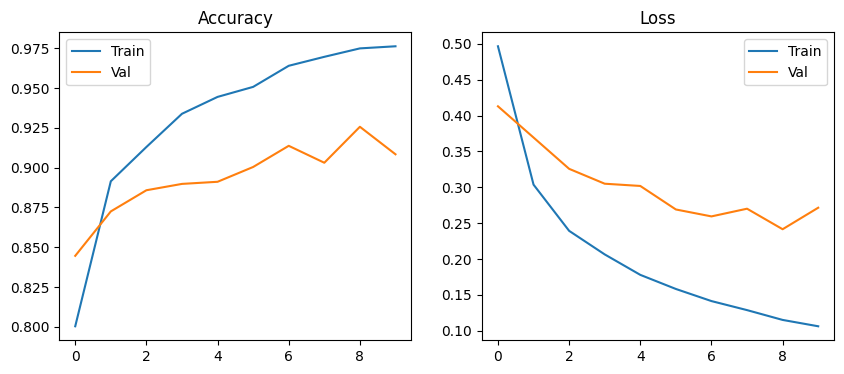

In [23]:
#Step 6 — Plot Training History

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Val')
plt.title('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Val')
plt.title('Loss')
plt.legend()
plt.show()


24/24 ━━━━━━━━━━━━━━━━━━━━ 8s 294ms/step
Class indices mapping: {'benign': 0, 'malignant': 1, 'normal': 2}
Class names in order: ['benign', 'malignant', 'normal']
Classification Report:

              precision    recall  f1-score   support

      benign       0.33      0.33      0.33       249
   malignant       0.36      0.34      0.35       256
      normal       0.35      0.37      0.36       248

    accuracy                           0.35       753
   macro avg       0.35      0.35      0.35       753
weighted avg       0.35      0.35      0.35       753



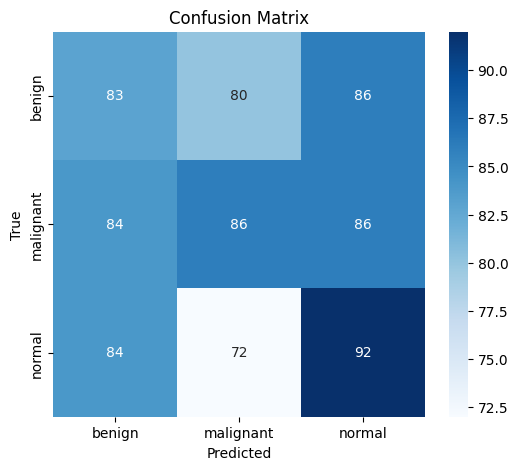

In [24]:
#Step 7 — Evaluation & Classification Report


import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf

# Load the best saved model
model = tf.keras.models.load_model(MODEL_PATH)

# Reset the validation generator
val_gen.reset()

# Predict on validation set
preds = model.predict(val_gen, verbose=1)
y_pred = np.argmax(preds, axis=1)

# True labels
y_true = val_gen.classes  # This must be used, NOT class_indices

# Check mapping of class names
print("Class indices mapping:", val_gen.class_indices)
# Adjust CLASSES to match the order of class_indices
CLASSES = [k for k, v in sorted(val_gen.class_indices.items(), key=lambda item: item[1])]
print("Class names in order:", CLASSES)

# Classification report
print("Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=CLASSES))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot confusion matrix
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASSES, yticklabels=CLASSES)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()




In [25]:
import numpy as np
import cv2
from PIL import Image
import tensorflow as tf

CLASSES = ["normal", "benign", "malignant"]

def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    # Model mapping input to last conv layer output + predictions
    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    # Compute gradients
    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]

    # Reshape pooled_grads for broadcasting
    pooled_grads = tf.reshape(pooled_grads, (1, 1, -1))
    heatmap = tf.reduce_sum(conv_outputs * pooled_grads, axis=-1)

    # Normalize heatmap
    heatmap = tf.maximum(heatmap, 0)
    heatmap /= tf.reduce_max(heatmap) + 1e-10

    return heatmap.numpy()


def display_gradcam(image_path, model, last_conv_layer_name):
    # Load and preprocess image
    img = Image.open(image_path).convert("RGB")
    img_resized = img.resize((224, 224))
    img_array = np.expand_dims(np.array(img_resized)/255.0, axis=0)

    # Prediction
    preds = model.predict(img_array)
    pred_class = np.argmax(preds)

    # Generate Grad-CAM heatmap
    heatmap = make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=pred_class)
    heatmap = cv2.resize(heatmap, (224, 224))
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    # Overlay heatmap on original image
    img_uint8 = np.array(img_resized, dtype=np.uint8)
    overlay = cv2.addWeighted(img_uint8, 0.6, heatmap, 0.4, 0)
    overlay = cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB)

    return overlay, CLASSES[pred_class] 





1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


c:\Users\zaina\Downloads\AI DISEASE PREDICTION\venv\Lib\site-packages\keras\src\models\functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['input_layer_3']]
Received: inputs=Tensor(shape=(1, 128, 128, 3))
  warnings.warn(msg)


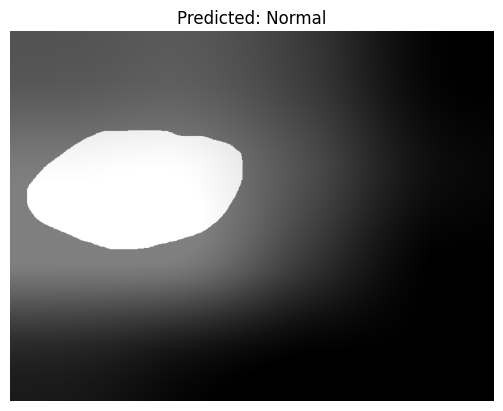

In [26]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import tensorflow as tf
from tensorflow.keras.models import Model

# === Step 1: Define dataset folder, last conv layer name, and class names ===
DATA_DIR = r"C:\Users\zaina\Downloads\AI DISEASE PREDICTION\Dataset_BUSI_with_GT_split\test"
last_conv_layer_name = "Conv_1"   # Change to your model's actual last conv layer name
class_names = ["Normal", "Benign", "Malignant"]

# === Step 2: Automatically get first image from dataset folder ===
test_image_path = None
for root, dirs, files in os.walk(DATA_DIR):
    for file in files:
        if file.lower().endswith((".png", ".jpg", ".jpeg")):
            test_image_path = os.path.join(root, file)
            break
    if test_image_path:
        break

if not test_image_path:
    raise FileNotFoundError("No image found in the dataset folder!")

# === Step 3: Define display_gradcam function ===
def display_gradcam(image_path, model, last_conv_layer_name):
    img = Image.open(image_path).convert("RGB")
    img_resized = img.resize((128, 128))
    img_array = np.expand_dims(np.array(img_resized)/255.0, axis=0)

    # Prediction
    preds = model.predict(img_array)
    pred_class = np.argmax(preds)
    predicted_label = class_names[pred_class]

    # Grad-CAM
    grad_model = Model(
        inputs=[model.inputs],
        outputs=[model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        loss = predictions[:, pred_class]

    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0].numpy()
    for i in range(conv_outputs.shape[-1]):
        conv_outputs[:, :, i] *= pooled_grads[i].numpy()

    heatmap = np.mean(conv_outputs, axis=-1)
    heatmap = np.maximum(heatmap, 0)
    heatmap /= np.max(heatmap) if np.max(heatmap) != 0 else 1

    heatmap = np.uint8(255 * heatmap)
    heatmap = Image.fromarray(heatmap).resize(img.size)
    heatmap = np.array(heatmap)

    overlay = np.array(img)
    overlay = np.uint8(0.5 * overlay + 0.5 * np.stack([heatmap]*3, axis=-1))

    return overlay, predicted_label

# === Step 4: Generate Grad-CAM and display ===
overlay, predicted_label = display_gradcam(test_image_path, model, last_conv_layer_name)

plt.imshow(overlay)
plt.title(f"Predicted: {predicted_label}")
plt.axis('off')
plt.show()


In [27]:
for layer in model.layers:
    if 'conv' in layer.name:
        print(layer.name)


expanded_conv_depthwise
expanded_conv_depthwise_BN
expanded_conv_depthwise_relu
expanded_conv_project
expanded_conv_project_BN


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
Predicted Class: malignant
Class Probabilities: {'benign': np.float32(0.37904945), 'malignant': np.float32(0.559956), 'normal': np.float32(0.060994547)}


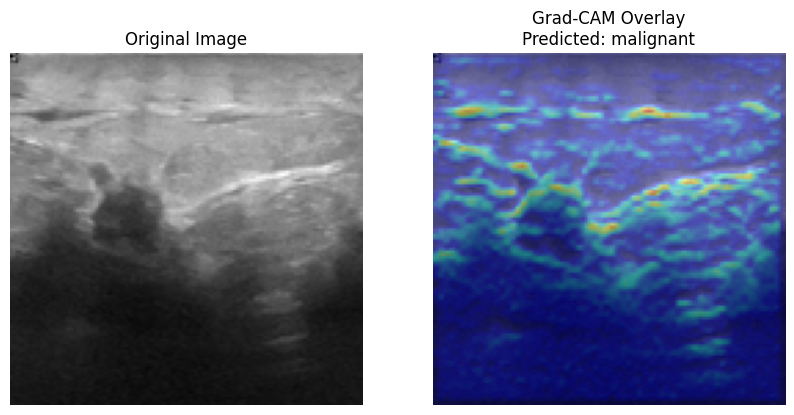

In [28]:
import matplotlib.pyplot as plt
import cv2
from PIL import Image
import numpy as np
import tensorflow as tf

# Make sure CLASSES matches training generator order
CLASSES = list(train_gen.class_indices.keys())  # ['normal', 'benign', 'malignant']

# Ask user for image path
test_image_path = input("Enter the full path of the image: ")

# --------------------------
# Function to generate Grad-CAM heatmap
# --------------------------
def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
        loss = predictions[:, pred_index]

    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))
    conv_outputs = conv_outputs[0].numpy()

    for i in range(conv_outputs.shape[-1]):
        conv_outputs[:,:,i] *= pooled_grads[i].numpy()

    heatmap = np.mean(conv_outputs, axis=-1)
    heatmap = np.maximum(heatmap, 0)
    heatmap /= np.max(heatmap) if np.max(heatmap) != 0 else 1
    return heatmap

# --------------------------
# Function to predict and generate Grad-CAM overlay
# --------------------------
def display_gradcam(image_path, model, last_conv_layer_name):
    # Load and preprocess image
    img = Image.open(image_path).convert("RGB")
    img_resized = img.resize((128,128))  # Resize to model input size
    img_array = np.expand_dims(np.array(img_resized)/255.0, axis=0)

    # Predict class
    preds = model.predict(img_array)
    pred_class = np.argmax(preds)

    # Generate Grad-CAM heatmap
    heatmap = make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=pred_class)
    heatmap = cv2.resize(heatmap, (128,128))
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    # Overlay heatmap on original image
    img_uint8 = np.array(img_resized, dtype=np.uint8)
    overlay = cv2.addWeighted(img_uint8, 0.6, heatmap, 0.4, 0)
    overlay = cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB)

    return overlay, preds

# --------------------------
# Get last conv layer automatically
# --------------------------
last_conv_layer_name = [layer.name for layer in model.layers if 'conv' in layer.name][-1]

# --------------------------
# Predict and display
# --------------------------
overlay, preds = display_gradcam(test_image_path, model, last_conv_layer_name)
pred_idx = np.argmax(preds)
predicted_label = CLASSES[pred_idx]

print(f"Predicted Class: {predicted_label}")
print(f"Class Probabilities: {dict(zip(CLASSES, preds[0]))}")

# Display original and overlay
img = Image.open(test_image_path).convert("RGB")
img_resized = img.resize((128,128))

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(img_resized)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(overlay)
plt.title(f"Grad-CAM Overlay\nPredicted: {predicted_label}")
plt.axis("off")

plt.show()


In [29]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# --------------------------
# Step 1: Define test data generator
# --------------------------
test_datagen = ImageDataGenerator(rescale=1./255)  # Only rescale, no augmentation

# Path to test dataset
test_dir = r"C:\Users\zaina\Downloads\AI DISEASE PREDICTION\Dataset_BUSI_with_GT_split\test"

# Create test generator
test_gen = test_datagen.flow_from_directory(
    test_dir,
    target_size=(128,128),   # Must match model input
    batch_size=32,
    class_mode='categorical',
    shuffle=False             # Do not shuffle for evaluation
)

# --------------------------
# Step 2: Evaluate model
# --------------------------
loss, accuracy = model.evaluate(test_gen, verbose=1)

print(f"Test Accuracy: {accuracy*100:.2f}%")


Found 596 images belonging to 3 classes.


c:\Users\zaina\Downloads\AI DISEASE PREDICTION\venv\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


19/19 ━━━━━━━━━━━━━━━━━━━━ 9s 354ms/step - accuracy: 0.9362 - loss: 0.1737
Test Accuracy: 93.62%


In [30]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

# Predict labels
preds = model.predict(test_gen)
y_pred = np.argmax(preds, axis=1)
y_true = test_gen.classes

print(confusion_matrix(y_true, y_pred))
print(classification_report(y_true, y_pred, target_names=list(test_gen.class_indices.keys())))


19/19 ━━━━━━━━━━━━━━━━━━━━ 4s 224ms/step
[[158  14   8]
 [ 10 194   4]
 [  2   0 206]]
              precision    recall  f1-score   support

      benign       0.93      0.88      0.90       180
   malignant       0.93      0.93      0.93       208
      normal       0.94      0.99      0.97       208

    accuracy                           0.94       596
   macro avg       0.94      0.93      0.93       596
weighted avg       0.94      0.94      0.94       596

